In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import wide_resnet50_2, Wide_ResNet50_2_Weights
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
class FeatureExtractor(nn.Module):
    weights = Wide_ResNet50_2_Weights.DEFAULT
    transform = weights.transforms()

    def __init__(self):
        super().__init__()

        backbone = wide_resnet50_2(weights=self.weights)

        self.stage1 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1
        )

        self.stage2 = backbone.layer2
        self.stage3 = backbone.layer3

    def forward(self, x):
        x = self.stage1(x)
        f2 = self.stage2(x)
        f3 = self.stage3(f2)
        
        return {"layer2":f2, "layer3":f3}

In [4]:
def patchify(features):
    layer2 = features['layer2']
    layer3 = features['layer3']
    layer3 = F.interpolate(layer3, size = layer2.shape[-2:], mode = 'bilinear', align_corners=False)
    features = torch.cat([layer2,  layer3], dim = 1)
    B, C, H, W = features.shape
    features = features.permute(0, 2, 3, 1)
    features = features.reshape(B, H*W, C)
    patches = F.normalize(features, p=2, dim=-1)
    return patches

In [6]:
train_dataset = ImageFolder(
    root='MVTecAD/bottle/train',
    transform= FeatureExtractor.transform
)

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=False   
)

In [8]:
test_dataset = train_dataset = ImageFolder(
    root='MVTecAD/bottle/test/',
    transform=FeatureExtractor.transform
)

In [9]:
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle = False 
)

In [10]:
extractor = FeatureExtractor()
extractor = extractor.to(device)

In [11]:
extractor.eval()
for p in extractor.parameters():
    p.requires_grad = False

In [12]:
memory_bank = []

In [13]:
with torch.no_grad():
    for images,_ in train_loader:

        images = images.to(device)

        features = extractor(images)

        patches = patchify(features)

        memory_bank.append(patches.cpu())
memory_bank = torch.cat(memory_bank, dim=0)

In [14]:
memory_bank = memory_bank.reshape(-1, memory_bank.shape[-1])
memory_bank.shape

torch.Size([163856, 1536])

In [15]:
test_images, _ = next(iter(test_loader))

In [197]:
img_num = '000'

In [198]:
with torch.no_grad():
    features = extractor(test_images[int(img_num)].unsqueeze(0).to(device))
    test_patches = patchify(features)

In [199]:
B, P, D = test_patches.shape
test_patches = test_patches.reshape(-1, D)

In [200]:
distances = torch.cdist(test_patches, memory_bank.to(device))

In [201]:
min_distances, indices = distances.min(dim=1)

In [202]:
patch_scores = min_distances.reshape(B, 28, 28)
anomaly_map = F.interpolate(patch_scores.unsqueeze(0), size=(224,224), mode='bilinear')
anomaly_map = (anomaly_map - anomaly_map.min()) / (anomaly_map.max()-anomaly_map.min())
anomaly_map = anomaly_map.squeeze(0)
anomaly_map.shape

torch.Size([1, 224, 224])

In [203]:
img = Image.open(f'MVTecAD/bottle/test/broken_large/{img_num}.png').convert('RGB').resize((224,224))
msk = Image.open(f'MVTecAD/bottle/ground_truth/broken_large/{img_num}_mask.png').convert('L').resize((224,224))

In [204]:
m = np.array(msk)
m.dtype

dtype('uint8')

In [205]:
threshold = 0.74

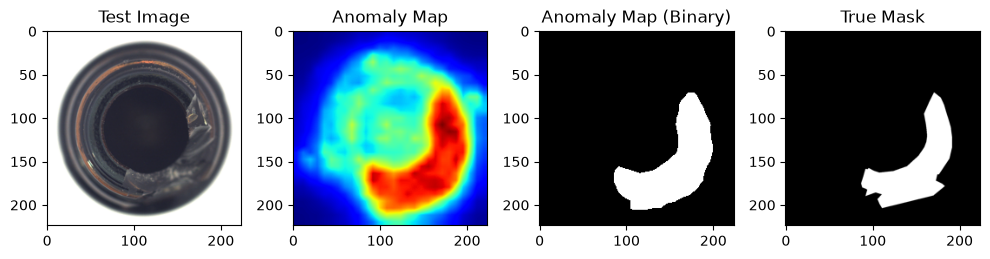

In [206]:
plt.figure(figsize = (10,8))
plt.subplot(1,4,1)
plt.imshow(img)
plt.title('Test Image')

plt.subplot(1,4,2)
plt.imshow(anomaly_map[0].cpu(), cmap = 'jet')
plt.title('Anomaly Map')

plt.subplot(1,4,3)
plt.imshow((anomaly_map[0] > threshold).cpu(), cmap = 'gray')
plt.title('Anomaly Map (Binary)')

plt.subplot(1,4,4)
plt.imshow(msk, cmap = 'gray')
plt.title('True Mask')
plt.tight_layout()
plt.show()